In [66]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot  as plt
import seaborn as sns 
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [67]:
data = pd.read_csv('Bank_Personal_Loan_Modelling(1).csv')
df = pd.DataFrame(data)
df  

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1/90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0/40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0/30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0/50,2,0,0,0,0,1,0


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e0e0e0; border-radius: 8px; padding: 25px;max-width: 96%;
 background-color: #fafafa; text-align: left;">
    <h2 style="color: #141414ff; border-bottom: 2px solid #3498db; padding-bottom: 10px; margin-top: 0;">
        Data Dictionary 🏦
    </h2>
    <p><strong style="color: #3498db;">ID:</strong> A unique identifier for each customer. This column is not useful for modeling and can be dropped later.</p>
    <p><strong style="color: #3498db;">Age:</strong> The customer's age in years.</p>
    <p><strong style="color: #3498db;">Experience:</strong> The customer's professional experience in years.</p>
    <div style="background-color: #eaf5ff; border-left: 5px solid #3498db; padding: 15px; margin: 15px 0; border-radius: 5px;">
        <p style="margin:0;"><strong>Important Note:</strong> This column contains negative values (e.g., <code>-3</code>), which is not logical. This is a data error that must be corrected during the preprocessing phase (e.g., by replacing them with their absolute value).</p>
    </div>
    <p><strong style="color: #3498db;">Income:</strong> The customer's annual income in thousands of dollars. (e.g., a value of <code>60</code> means $60,000).</p>
    <p><strong style="color: #3498db;">ZIP Code:</strong> The customer's residential ZIP code. While numerical, it represents a geographical area.</p>
    <p><strong style="color: #3498db;">Family:</strong> The number of members in the customer's family.</p>
    <p><strong style="color: #3498db;">CCAvg:</strong> The average monthly credit card spending in thousands of dollars.</p>
    <div style="background-color: #eaf5ff; border-left: 5px solid #3498db; padding: 15px; margin: 15px 0; border-radius: 5px;">
        <p style="margin:0;"><strong>Important Note:</strong> The data type of this column is a string and must be converted to a numeric type. Values like <code>"1/60"</code> should be converted to <code>1.6</code>.</p>
    </div>
    <p><strong style="color: #3498db;">Education:</strong> The customer's education level, encoded numerically:</p>
    <ul style="list-style-type: none; padding-left: 20px;">
        <li><strong style="color: #2980b9;">1:</strong> Undergraduate</li>
        <li><strong style="color: #2980b9;">2:</strong> Graduate</li>
        <li><strong style="color: #2980b9;">3:</strong> Advanced/Professional</li>
    </ul>
    <p><strong style="color: #3498db;">Mortgage:</strong> The value of the customer's house mortgage in thousands of dollars. A value of <code>0</code> means no mortgage.</p>
    <p><strong style="color: #e74c3c;">Personal Loan (Target):</strong> Indicates if the customer accepted a personal loan.</p>
    <ul style="list-style-type: none; padding-left: 20px;">
        <li><b>0:</b> No</li>
        <li><b>1:</b> Yes</li>
    </ul>
    <div style="background-color: #fff5e6; border-left: 5px solid #f39c12; padding: 15px; margin: 15px 0; border-radius: 5px;">
        <p style="margin:0;"><strong>Key Insight:</strong> Only about 9.6% of customers accepted the loan. This means our dataset is highly <b>imbalanced</b>, which is a critical consideration for the modeling phase.</p>
    </div>
    <p><strong style="color: #3498db;">Securities Account:</strong> Does the customer have a securities account with this bank? (<code>0</code> for No, <code>1</code> for Yes).</p>
    <p><strong style="color: #3498db;">CD Account:</strong> Does the customer have a Certificate of Deposit (CD) account? (<code>0</code> for No, <code>1</code> for Yes).</p>
    <p><strong style="color: #3498db;">Online:</strong> Does the customer use online banking services? (<code>0</code> for No, <code>1</code> for Yes).</p>
    <p><strong style="color: #3498db;">CreditCard:</strong> Does the customer have a credit card issued by this bank? (<code>0</code> for No, <code>1</code> for Yes).</p>

</div>

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


In [69]:
df['CCAvg'] = df['CCAvg'].str.replace('/', '.').astype(float)
df['CCAvg']

0       1.6
1       1.5
2       1.0
3       2.7
4       1.0
       ... 
4995    1.9
4996    0.4
4997    0.3
4998    0.5
4999    0.8
Name: CCAvg, Length: 5000, dtype: float64

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [71]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [72]:
df['Experience'] = df['Experience'].abs()
df.describe()


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.134600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.415189,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,0.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px;">
    <h3 style="color: #c0392b; margin-top: 0;">
        Key Finding: Severe Class Imbalance  imbalance
    </h3>
    <p style="font-size: 16px;">
        The percentage of individuals who were <strong>not offered a loan</strong> is significantly higher than those who were. 
        <span style="background-color: #f9e6e6; border: 1px solid #e74c3c; padding: 3px 6px; border-radius: 4px; font-weight: bold; color: #c0392b;">
            (Approximately 4520 customers were not offered a loan, while only 480 were).
        </span>
    </p>
    <p style="font-size: 16px;">
        This disproportionate ratio is a recurring pattern observed across other categorical columns as well.
    </p>
</div>

In [73]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [74]:
df.drop(['ID'], axis=1, inplace=True)
df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [75]:
loan_counts = df['Personal Loan'].value_counts()
print("Distribution of Personal Loan offers:")
print(loan_counts)
loan_percent = loan_counts*100 / len(df['Personal Loan'])
print(loan_percent)

Distribution of Personal Loan offers:
Personal Loan
0    4520
1     480
Name: count, dtype: int64
Personal Loan
0    90.4
1     9.6
Name: count, dtype: float64


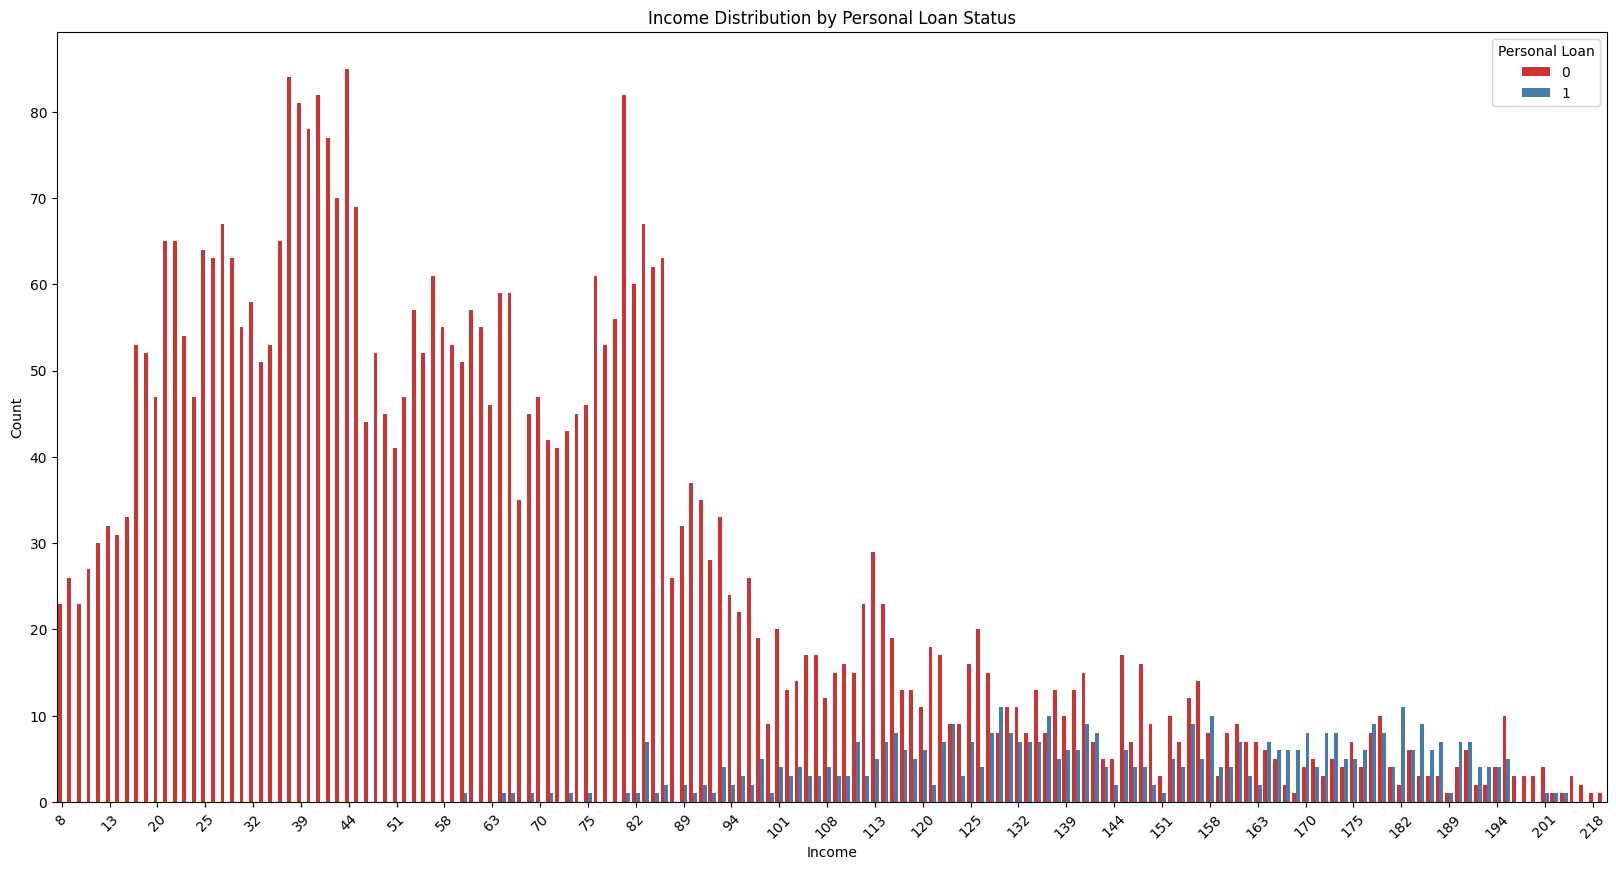

In [76]:
plt.figure(figsize=(20, 10))
ax = sns.countplot(data=df, x='Income', hue='Personal Loan', palette='Set1', width=0.8 ,)
plt.title('Income Distribution by Personal Loan Status')
plt.xlabel('Income')
plt.ylabel('Count')
plt.legend(title='Personal Loan', labels=df['Personal Loan'].unique())
xticks = ax.get_xticks()
ax.set_xticks(xticks[::5])  # نمایش هر 5 تیک
plt.xticks(rotation=45)
plt.show()


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Analysis of Income Distribution
    </h3>
    <p style="font-size: 16px;">
        A large number of individuals have low incomes, while a small number have high incomes. This indicates that the income distribution is <strong>right-skewed</strong>. The majority of the bank's customers have low to moderate incomes.
    </p>
    <div style="background-color: #f0f8ff; border-left: 4px solid #3498db; padding: 15px; margin-top: 15px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px;">
            <strong>Key Observation:</strong> We can see that the loan offer is primarily extended to this smaller group of individuals with high incomes.
        </p>
    </div>
    
</div>

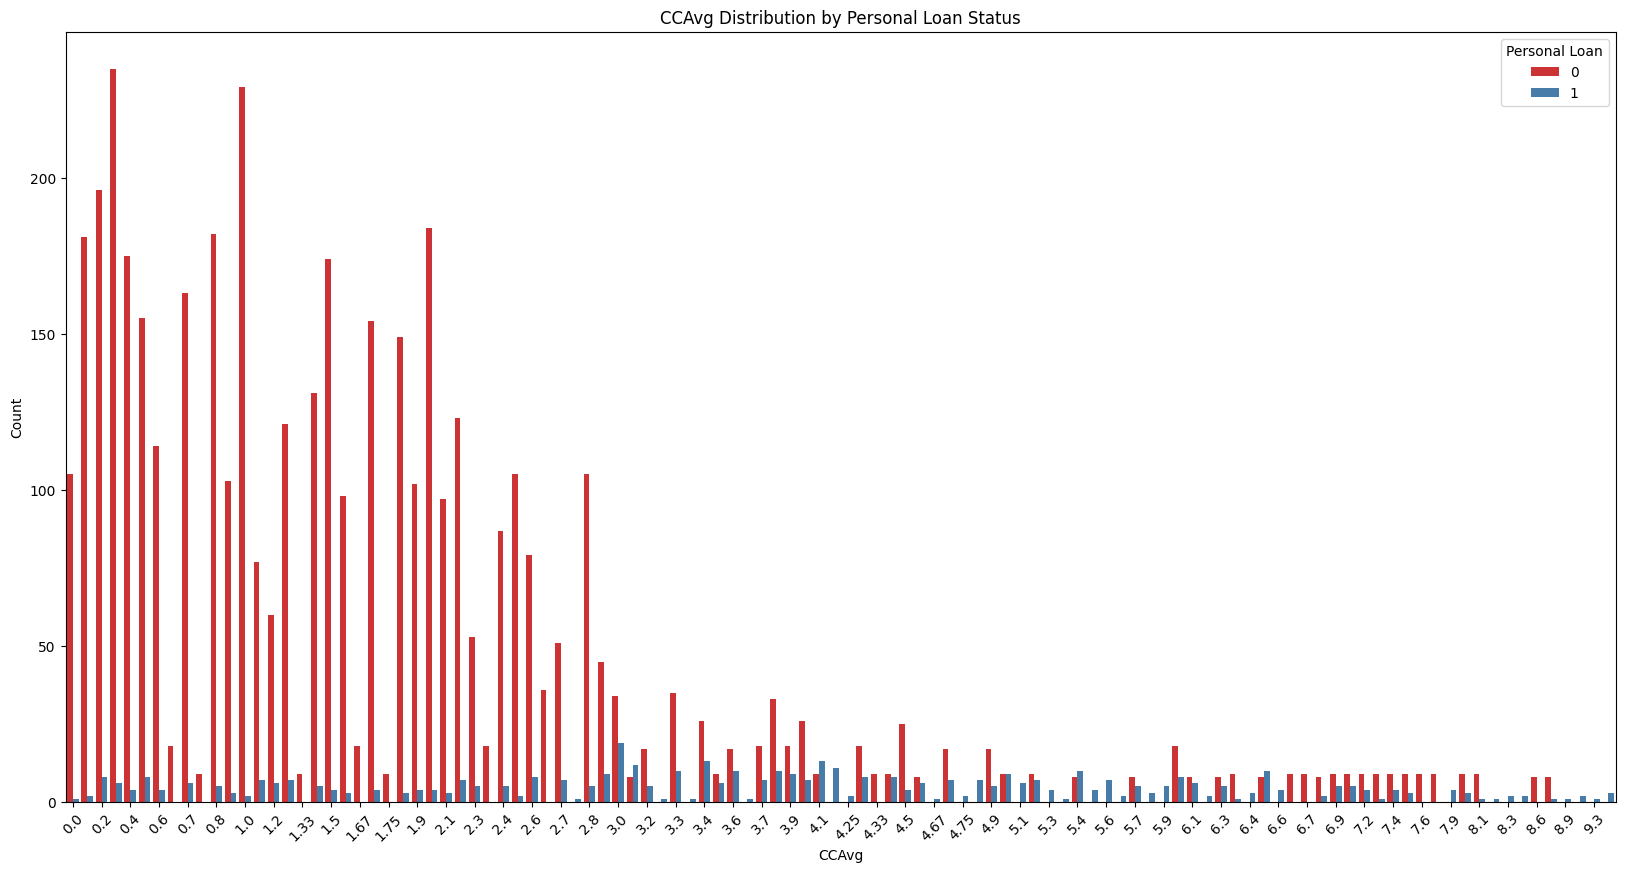

In [77]:
plt.figure(figsize=(20, 10))
ax = sns.countplot(data=df, x='CCAvg', hue='Personal Loan', palette='Set1', width=0.8)
plt.title('CCAvg Distribution by Personal Loan Status')
plt.xlabel('CCAvg')
plt.ylabel('Count')
plt.legend(title='Personal Loan', labels=df['Personal Loan'].unique())
plt.xticks(rotation=45)
ax.set_xticks(ax.get_xticks()[::2])
plt.show()

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Analysis of Credit Card Spending (CCAvg)
    </h3>
    <p style="font-size: 16px;">
        The absolute number of customers who received a loan (represented by the blue bars) is small within each category.
    </p>
    <p style="font-size: 16px;">
        However, when looking at the entire customer base (predominantly the red bars), it's clear that the number of customers with lower credit card spending is far greater than those with high spending habits.
    </p>
    <div style="background-color: #eaf5ff; border-left: 4px solid #3498db; padding: 15px; margin-top: 15px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px;">
            <strong>Golden Rule:</strong> The key insight is that as we move to the right on the chart (towards higher spending), the ratio of loan acceptances increases dramatically. In other words, while the total number of high-spending customers is small, a significantly larger percentage of that group accepted the personal loan offer.
        </p>
    </div>
    
</div>

In [78]:
income_ccavg_skewness  = df[['Income', 'CCAvg']].skew()
print("\nSkewness of Income and CCAvg:")
print(income_ccavg_skewness)


Skewness of Income and CCAvg:
Income    0.841339
CCAvg     1.598443
dtype: float64


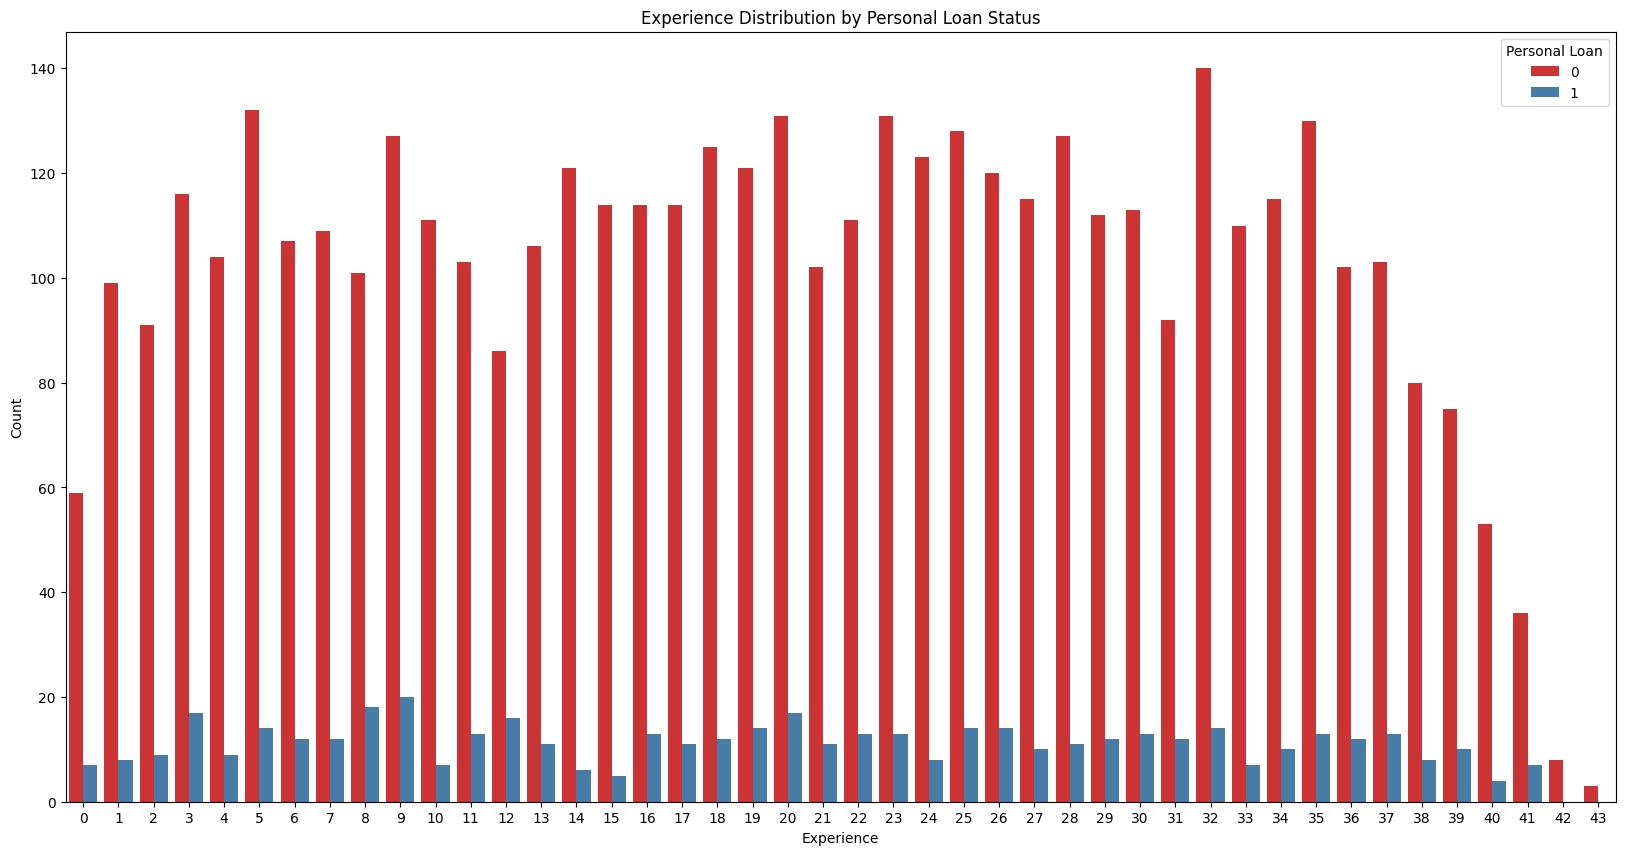

In [79]:
plt.figure(figsize=(20, 10))
ax = sns.countplot(data=df, x='Experience', hue='Personal Loan', palette='Set1', width=0.8)

plt.title('Experience Distribution by Personal Loan Status')
plt.xlabel('Experience')
plt.ylabel('Count')
plt.legend(title='Personal Loan', labels=df['Personal Loan'].unique())

plt.show()


این نمودار به ما نشون می‌ده که متغیر Experience (سابقه کار) به تنهایی، یک پیش‌بینی‌کننده قوی برای پذیرش وام نیست.

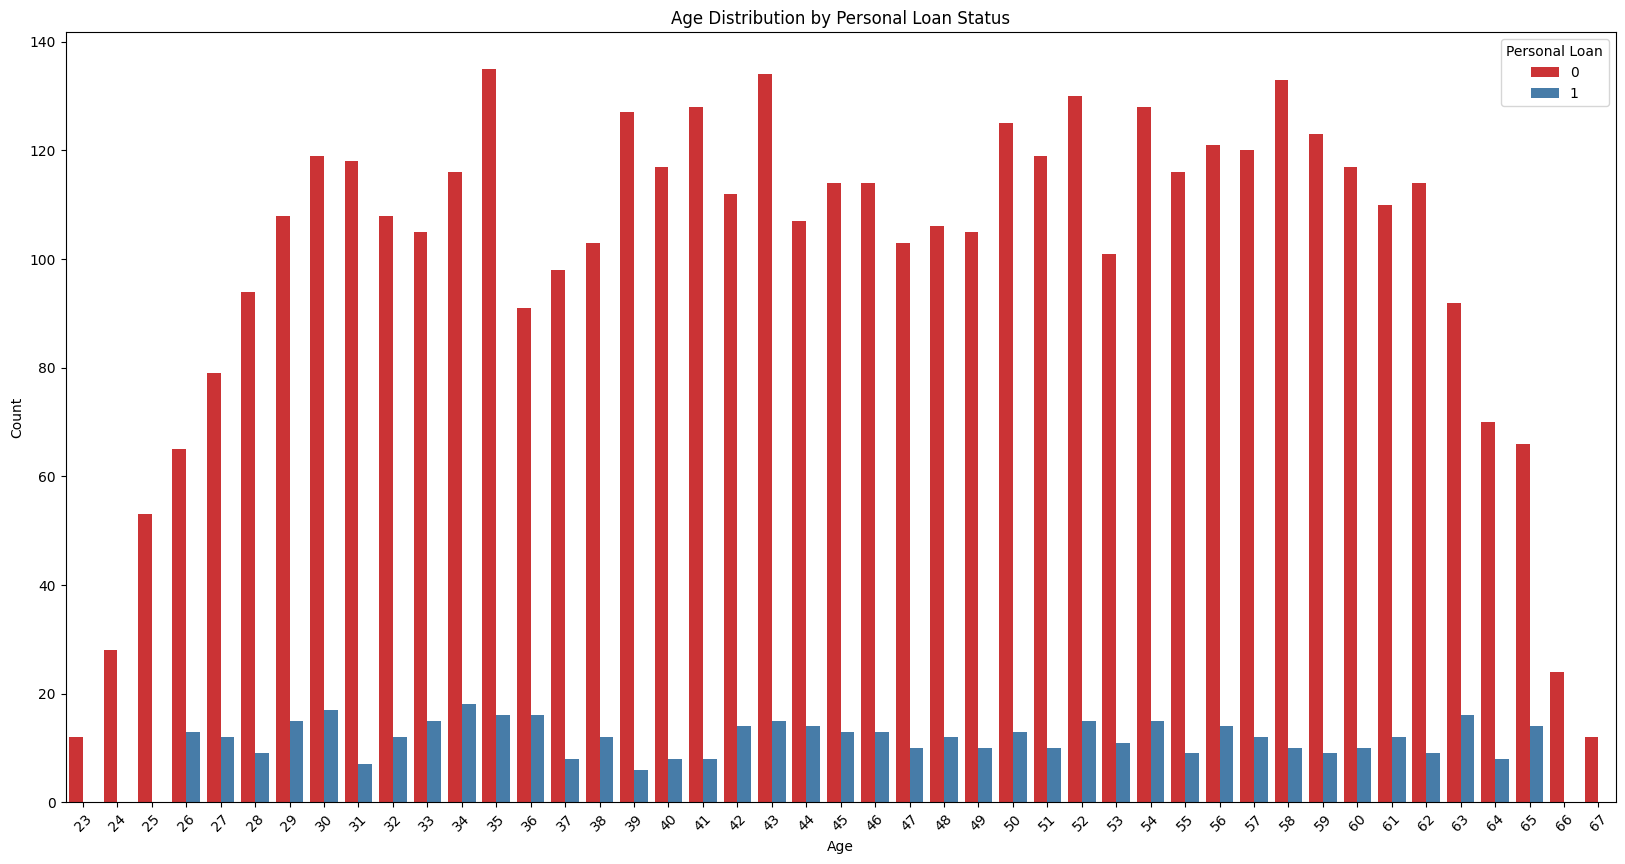

In [80]:
plt.figure(figsize=(20, 10))

sns.countplot(data=df,x='Age',hue='Personal Loan',palette='Set1',width=0.8)
plt.title('Age Distribution by Personal Loan Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Personal Loan', labels=df['Personal Loan'].unique())
plt.xticks(rotation=45)
plt.show()


زیر 26 سال پیشنهاد وام نداریم

#
#


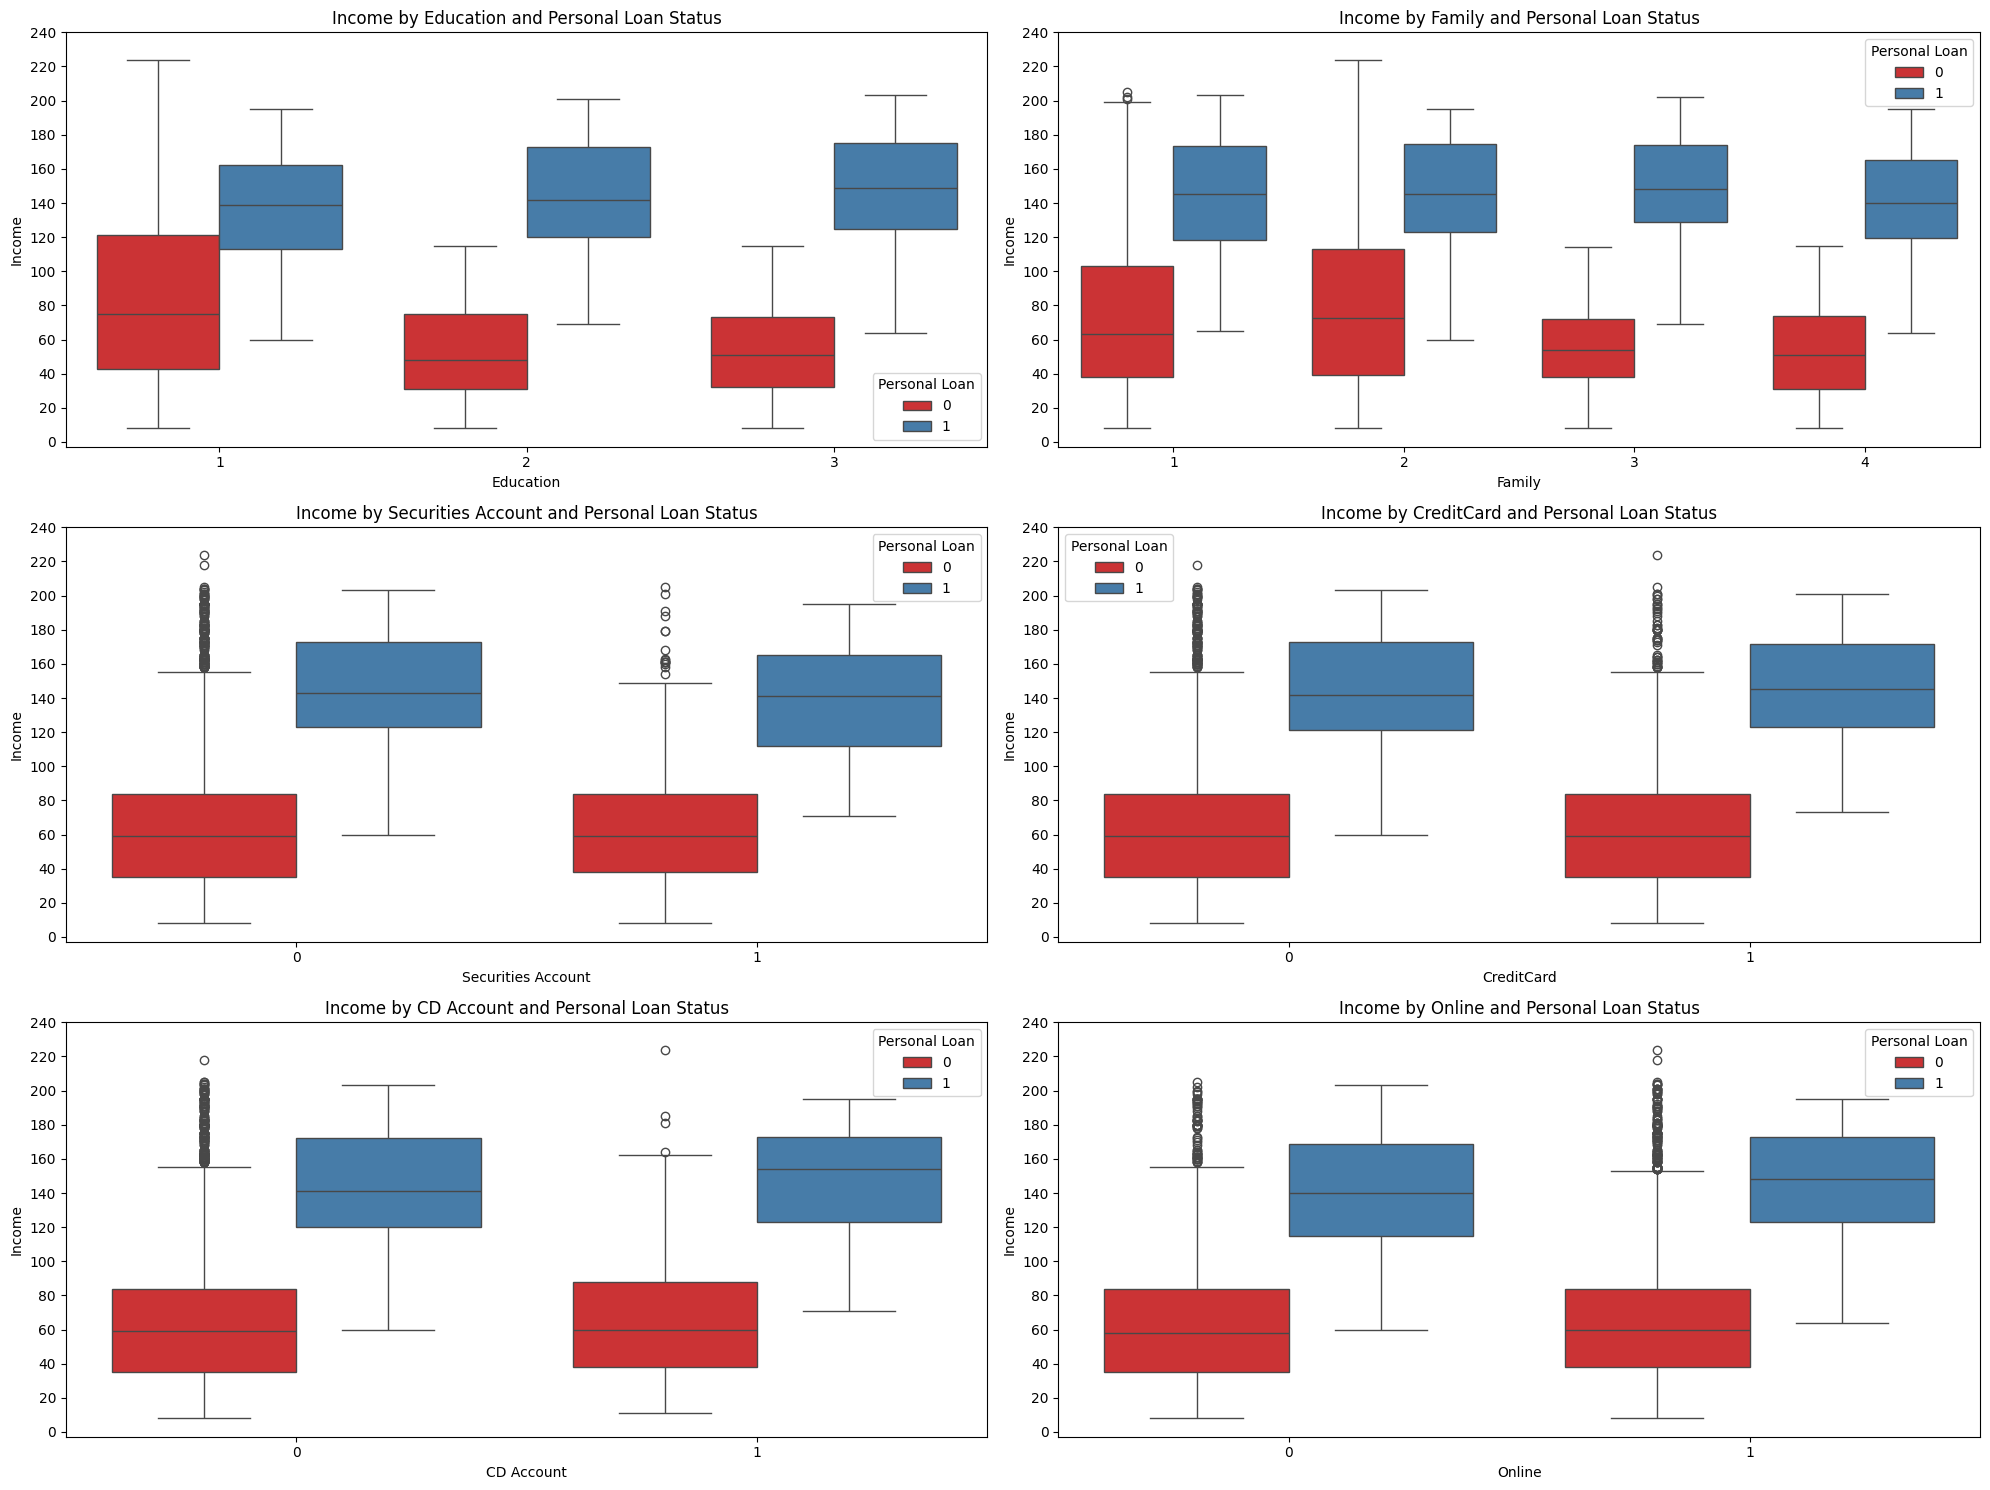

In [81]:
category_col = ['Education','Family','Securities Account','CreditCard','CD Account','Online']

# Plot boxplots of Income by each categorical column and Personal Loan status
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
axes = axes.flatten()

for idx, col_name in enumerate(category_col):
    sns.boxplot(
        data=df,
        x=col_name,
        y='Income',
        hue='Personal Loan',
        palette='Set1',
        ax=axes[idx]
    )
    axes[idx].set_title(f'Income by {col_name} and Personal Loan Status')
    axes[idx].set_yticks(np.arange(0, df['Income'].max() + 20, 20))

plt.tight_layout()
plt.show()
    


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h2 style="color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px; margin-top: 0; ">
        Box Plot Analysis Summary
    </h2>
    <h3 style="color: #2980b9;">Analysis of the Education Chart:</h3>
    <p style="font-size: 16px;">
        The median income for individuals who were offered a loan is higher across all three education levels. This suggests that monthly income is a significant feature in the loan offer decision.<br>
        Additionally, the dispersion (size of the box) for those who were not offered a loan is high in the undergraduate category, and the upper whisker of this box indicates that there are individuals in this group with higher incomes than the rest.
    </p>
    <hr style="border: 0; height: 1px; background-color: #e0e0e0; margin: 20px 0;">
    <h3 style="color: #2980b9;">Analysis of the Family Chart:</h3>
    <p style="font-size: 16px;">
        The median income for those offered a loan is higher across all four family size groups compared to those who were not. The dispersion among customers in the second group is higher, and the median for this group is greater than the other groups in the "not offered" category.<br>
        We also observe individuals in this group who, despite not being offered a loan, have a high income (indicated by the upper whisker).
    </p>
    <hr style="border: 0; height: 1px; background-color: #e0e0e0; margin: 20px 0;">
    <h3 style="color: #2980b9;">Analysis of the Securities Account Chart:</h3>
    <p style="font-size: 16px;">
        Customers who were offered a loan have a higher median income than those who were not.<br>
        The median income for those not offered a loan is comparable to the lower whisker of the box for customers who were offered a loan. Furthermore, a significant number of outliers are observed among those who were not offered a loan.
    </p>
    <hr style="border: 0; height: 1px; background-color: #e0e0e0; margin: 20px 0;">
    <h3 style="color: #2980b9;">Analysis of the Credit Card Chart:</h3>
    <p style="font-size: 16px;">
        The median income for those offered a loan is almost at the same level as the upper whisker for customers who were not. Considering the size of the boxes, it can be said that they have a similar dispersion, and the number of outliers among those who were not offered a loan is quite high.
    </p>
</div>
<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #f0f8ff; text-align: left; margin-top: 20px; max-width: 96%;">
    <h2 style="color: #c0392b; border-bottom: 2px solid #e74c3c; padding-bottom: 10px; margin-top: 0;">
        Key Analytical Questions ❓
    </h2>
    <h3 style="color: #2980b9;">First Key Question:</h3>
    <p style="font-size: 16px;">
        Why were individuals with high incomes not offered a loan? For example, in the education chart, undergraduates have higher incomes but were often not offered a loan.
    </p>
    <hr style="border: 0; height: 1px; background-color: #d0d0d0; margin: 20px 0;">
    <h3 style="color: #2980b9;">Second Question:</h3>
    <p style="font-size: 16px;">
        Is it possible that some columns, such as having a credit card or a securities account, have a significant impact? This is not immediately obvious from the charts.
    </p>
    <hr style="border: 0; height: 1px; background-color: #d0d0d0; margin: 20px 0;">
    <h3 style="color: #2980b9;">Third Question:</h3>
    <p style="font-size: 16px;">
        What is the minimum income for individuals in each group (loan offered vs. not offered)?
    </p>
</div>

In [82]:
undergraduate_df = df[df['Education']==1]


undergraduate_Edu_CCAvg = undergraduate_df['Income'].describe()
print(undergraduate_Edu_CCAvg)

print('*'*80)

comparison_undergraduate_Income = undergraduate_df.groupby('Personal Loan')['Income'].describe()
print(comparison_undergraduate_Income)

count    2096.000000
mean       85.586355
std        49.290965
min         8.000000
25%        43.750000
50%        79.000000
75%       123.000000
max       224.000000
Name: Income, dtype: float64
********************************************************************************
                count        mean        std   min    25%    50%    75%    max
Personal Loan                                                                 
0              2003.0   83.204693  48.627363   8.0   42.5   75.0  121.0  224.0
1                93.0  136.881720  32.965018  60.0  113.0  139.0  162.0  195.0


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Income as the Primary Filter for Undergraduates
    </h3>
    <p style="font-size: 16px;">
        The data reveals a stark difference in the median income between the two groups of undergraduate customers:
    </p>
    <ul style="list-style-type: none; padding-left: 0;">
        <li style="background-color: #f9e6e6; border-left: 4px solid #c0392b; padding: 10px; margin-bottom: 10px; border-radius: 4px; font-size: 16px;">
            Among the <strong>2,003</strong> customers who were <strong>not offered</strong> a loan, the median (50th percentile) income is <strong>$75,000</strong>.
        </li>
        <li style="background-color: #eaf5ff; border-left: 4px solid #2980b9; padding: 10px; border-radius: 4px; font-size: 16px;">
            Among the <strong>93</strong> customers who <strong>were offered</strong> a loan, the median (50th percentile) income is <strong>$139,000</strong>.
        </li>
    </ul>
    <div style="background-color: #f0f8ff; border: 1px solid #3498db; padding: 15px; margin-top: 20px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px; color: #2c3e50;">
            <strong>Conclusion:</strong> For an undergraduate customer to even be on the bank's radar for a loan offer, they must have a significantly higher income. This appears to be the primary filter and the first step in the decision-making process.
        </p>
    </div>
    
</div>

In [83]:
undergraduate_df = df[df['Education']==1]


undergraduate_Edu_CCAvg = undergraduate_df['CCAvg'].describe()
print(undergraduate_Edu_CCAvg)

print('*'*80)

comparison_undergraduate_CCAvg = undergraduate_df.groupby('Personal Loan')['CCAvg'].describe()
print(comparison_undergraduate_CCAvg)

count    2096.000000
mean        2.260830
std         2.039443
min         0.000000
25%         0.700000
50%         1.700000
75%         2.900000
max         8.800000
Name: CCAvg, dtype: float64
********************************************************************************
                count      mean       std  min  25%  50%  75%  max
Personal Loan                                                     
0              2003.0  2.201832  2.022038  0.0  0.7  1.7  2.8  8.8
1                93.0  3.531505  2.008681  0.2  2.0  3.5  4.9  8.5


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        CCAvg as a Differentiating Factor
    </h3>
    <p style="font-size: 16px;">
        The data shows that the median <strong>CCAvg</strong> for the group that received a loan (<strong>$3.5k</strong>) is more than double that of the group that did not (<strong>$1.7k</strong>).
    </p>
    <div style="background-color: #f0f8ff; border: 1px solid #3498db; padding: 15px; margin-top: 20px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px; color: #2c3e50;">
            <strong>Conclusion:</strong> High income alone is not sufficient. Among high-income individuals, the bank seems to prefer those with a more active financial profile, as demonstrated by higher credit card spending. This behavior likely provides the bank with greater confidence in the applicant's financial stability.
        </p>
    </div>
    
</div>

In [84]:
undergraduate_df = df[df['Education']==1]


undergraduate_Edu_CCAvg = undergraduate_df['Mortgage'].describe()
print(undergraduate_Edu_CCAvg)

print('*'*80)

comparison_undergraduate_morgage = undergraduate_df.groupby('Personal Loan')['Mortgage'].describe()
print(comparison_undergraduate_morgage)

count    2096.000000
mean       61.627385
std       110.257109
min         0.000000
25%         0.000000
50%         0.000000
75%       103.250000
max       635.000000
Name: Mortgage, dtype: float64
********************************************************************************
                count        mean         std  min  25%  50%    75%    max
Personal Loan                                                             
0              2003.0   59.000999  106.472131  0.0  0.0  0.0  101.0  635.0
1                93.0  118.193548  163.569109  0.0  0.0  0.0  227.0  617.0


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        The Nuanced Role of Mortgages
    </h3>
    <p style="font-size: 16px;">
        This is the most interesting part of the story. The <strong>median</strong> (50th percentile) mortgage value for both groups (those who received a loan and those who did not) is <strong>zero!</strong>
    </p>
    <div style="background-color: #f0f8ff; border: 1px solid #3498db; padding: 15px; margin-top: 20px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px; color: #2c3e50;">
            <strong>Conclusion:</strong> This implies that having a mortgage is not a decisive factor for most individuals, as the majority do not have one.
            <br><br>
            However, the more subtle insight is that the <em>mean</em> mortgage value for the group that received a loan (<strong>$118k</strong>) is significantly higher than for the other group (<strong>$59k</strong>). This suggests that if an individual does have a mortgage, having a larger one is not a negative factor and, in fact, correlates with receiving a personal loan! <em>(Perhaps it serves as an indicator of higher creditworthiness).</em>
        </p>
    </div>
    
</div>
<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #c0392b; margin-top: 0;">
        Answering a Key Question: Why Are High-Income Undergraduates Rejected?
    </h3>
    <div style="background-color: #f9e6e6; border-left: 4px solid #c0392b; padding: 15px; margin-top: 15px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px;">
            <strong>Answer:</strong> An undergraduate with a high income might not receive a loan because they likely lack the second most important factor: a <strong>high monthly credit card spending (CCAvg)</strong>.
            <br><br>
            Our analysis showed that this factor can be even more differentiating than income itself. The mortgage factor plays a much smaller role in this decision, as most individuals in both groups do not have a mortgage to begin with.
        </p>
    </div>
    
</div>

In [85]:
print(df['Family'].value_counts()*100/len(df['Family']))
family_df = df[df['Family']==1]

family1_CCAvg_des = family_df['CCAvg'].describe()
print(family1_CCAvg_des)

comparison_family1_CCAvg = family_df.groupby('Personal Loan')['CCAvg'].describe()
print(comparison_family1_CCAvg)

Family
1    29.44
2    25.92
4    24.44
3    20.20
Name: count, dtype: float64
count    1472.000000
mean        2.065591
std         1.834348
min         0.000000
25%         0.787500
50%         1.500000
75%         2.800000
max        10.000000
Name: CCAvg, dtype: float64
                count      mean       std  min   25%  50%   75%   max
Personal Loan                                                        
0              1365.0  1.932418  1.742884  0.0  0.70  1.5  2.67   8.6
1               107.0  3.764486  2.113039  0.0  2.55  3.6  4.85  10.0


In [86]:
family_df = df[df['Family']==1]
family1_Experience_des = family_df['Experience'].describe()
print(family1_Experience_des)

comparison_family1_Experience = family_df.groupby('Personal Loan')['Experience'].describe()
print(comparison_family1_Experience)

count    1472.000000
mean       20.614130
std        10.851097
min         0.000000
25%        11.000000
50%        21.000000
75%        29.000000
max        42.000000
Name: Experience, dtype: float64
                count       mean        std  min   25%   50%   75%   max
Personal Loan                                                           
0              1365.0  20.711355  10.798687  0.0  11.0  21.0  28.0  42.0
1               107.0  19.373832  11.479698  1.0   9.0  20.0  29.0  41.0


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Analysis of the 'Experience' Feature: A Non-Predictor
    </h3>
    <p style="font-size: 16px;">
        A detailed statistical comparison reveals that the 'Experience' feature has a surprisingly weak relationship with the loan offer outcome:
    </p>
    <ul style="list-style-type: none; padding-left: 0; font-size: 16px;">
        <li style="background-color: #f7f7f7; padding: 10px; border-left: 4px solid #7f8c8d; margin-bottom: 8px; border-radius: 4px;">
            <strong>Comparing Means:</strong> The mean experience for the no-loan group (<code>20.7</code>) and the loan group (<code>19.3</code>) are very close. A difference of only 1.4 years is not statistically significant.
        </li>
        <li style="background-color: #f7f7f7; padding: 10px; border-left: 4px solid #7f8c8d; margin-bottom: 8px; border-radius: 4px;">
            <strong>Comparing Medians (50%):</strong> This is even more telling. The median experience for the no-loan group (<code>21</code> years) and the loan group (<code>20</code> years) is almost identical, showing no real difference in the central tendency.
        </li>
        <li style="background-color: #f7f7f7; padding: 10px; border-left: 4px solid #7f8c8d; margin-bottom: 8px; border-radius: 4px;">
            <strong>Comparing Dispersion (std, 25%, 75%):</strong> Other statistics like the standard deviation and quartiles are also nearly the same for both groups.
        </li>
    </ul>
    <div style="background-color: #fff9e6; border: 1px solid #f39c12; padding: 15px; margin-top: 20px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px; color: #2c3e50;">
            <strong>Conclusion:</strong> 'Experience' is <strong>not</strong> a significant or determining factor for receiving a loan in this dataset.
            <br><br>
            Unlike powerful predictors such as <code>Income</code> and <code>CCAvg</code>, which showed a stark difference between the two groups, 'Experience' offers almost no differentiating power. Our machine learning model will likely learn to assign a very low weight to this feature or to ignore it entirely.
        </p>
    </div>
    
</div>

In [87]:
family1_no_loan = df[(df['Family'] == 1) & (df['Personal Loan'] == 0)]

income_99th_percentile = family1_no_loan['Income'].quantile(0.99)
print(income_99th_percentile)
high_income_outliers = family1_no_loan[family1_no_loan['Income'] > income_99th_percentile]
high_income_outliers

191.3599999999999


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
526,26,2,205,93106,1,6.33,1,271,0,0,0,0,1
740,52,27,195,90266,1,8.10,1,0,0,0,0,0,0
1067,50,24,195,95035,1,1.70,1,0,0,0,0,0,0
1307,26,2,195,94546,1,6.33,1,0,0,0,0,1,1
1432,26,2,195,90245,1,6.33,1,0,0,0,0,0,0
1552,29,5,195,94301,1,4.30,1,0,0,0,0,0,0
1711,27,3,201,95819,1,6.33,1,158,0,0,0,1,0
1783,53,27,192,94720,1,1.70,1,601,0,0,0,1,0
3483,60,36,195,90066,1,4.70,1,0,0,0,0,1,0
3608,59,35,202,94025,1,4.70,1,553,0,0,0,0,0


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h2 style="color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px; margin-top: 0;">
        Final Insights: The "Customer Loyalty" Factor
    </h2>
    <p style="font-size: 16px;">
        A deeper analysis of the high-income individuals who were rejected for a loan reveals several key patterns:
    </p>
    <ul style="list-style-type: none; padding-left: 0; font-size: 16px;">
        <li style="background-color: #f7f7f7; padding: 15px; border-left: 4px solid #7f8c8d; margin-bottom: 10px; border-radius: 4px;">
            <strong>Investment Accounts:</strong> For many of the rejected high-earners, the values for both <code>Securities Account</code> and <code>CD Account</code> are zero. This suggests that in addition to income and spending, the bank also values a deeper investment relationship with its customers.
        </li>
        <li style="background-color: #f7f7f7; padding: 15px; border-left: 4px solid #7f8c8d; margin-bottom: 10px; border-radius: 4px;">
            <strong>Mortgage Status:</strong> A significant number of these individuals (9 out of 14) also have no mortgage with the bank. This lack of a major financial commitment could be interpreted as a sign of lower loyalty or an insufficient credit history with this specific bank.
        </li>
    </ul>
    <div style="background-color: #eaf5ff; border: 1px solid #3498db; padding: 20px; margin-top: 20px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px; color: #2c3e50;">
            <strong>Overall Conclusion:</strong> High income and high credit card spending alone may not be sufficient for loan approval. The bank might view such customers with skepticism, assuming they spread their assets across multiple financial institutions. Consequently, the bank also appears to weigh factors that indicate customer loyalty and trust, such as having investment accounts or a mortgage with them, before extending a personal loan offer.
        </p>
    </div>
    
</div>

In [88]:
import pgeocode

nomi = pgeocode.Nominatim('us')


zip_code_str = df['ZIP Code'].astype(str)
zip_codes = zip_code_str.values 


location_info = nomi.query_postal_code(zip_codes)
selected_info = location_info[['postal_code', 'place_name', 'latitude', 'longitude']]


df['latitude'] = selected_info['latitude']
df['longitude'] = selected_info['longitude']



In [89]:
print(df['latitude'].isnull().sum())
print(df['longitude'].isnull().sum())

41
41


In [90]:
lat_median = df['latitude'].median()
lon_median = df['longitude'].median()

df['latitude'].fillna(lat_median,inplace=True)
df['longitude'].fillna(lon_median,inplace=True)

print(df['latitude'].isnull().sum())
print(df['longitude'].isnull().sum())

0
0


C:\Users\msi\AppData\Local\Temp\ipykernel_17812\2680377754.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\msi\AppData\Local\Temp\ipykernel_17812\2680377754.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [91]:
geoCode_no_loan = df[df['Personal Loan'] == 0][['latitude', 'longitude']]

geoCode_no_loan

,latitude,longitude
0,34.1510,-118.0889
1,33.7866,-118.2987
2,37.8738,-122.2549
3,37.7195,-122.4411
4,34.2283,-118.5368
...,...,...
4995,33.6485,-117.8387
4996,32.8455,-117.2521
4997,34.4451,-119.2565
4998,34.0290,-118.4005


In [92]:
import pandas as pd
import plotly.graph_objects as go


df_loan_yes = df[df['Personal Loan'] == 1]
df_loan_no = df[df['Personal Loan'] == 0]

fig = go.Figure()


fig.add_trace(go.Scattermapbox(
    lat=df_loan_no['latitude'],
    lon=df_loan_no['longitude'],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=9,
        color='red',
        opacity=0.7
    ),
    name='personal loan = 0', 
    hoverinfo='name'
))


fig.add_trace(go.Scattermapbox(
    lat=df_loan_yes['latitude'],
    lon=df_loan_yes['longitude'],
    mode='markers',
    marker=go.scattermapbox.Marker(
        size=9,
        color='blue',
        opacity=0.7
    ),
    name='personal loan = 1',
    hoverinfo='name'
))




fig.update_layout(
    title='Geographical dispersion of customers based on personal loan offers.',
    autosize=False,
    width=1800,  
    height=1000,  
    hovermode='closest',
    mapbox=dict(
        style='open-street-map', 
        bearing=0,
        center=dict(
            lat=df['latitude'].mean(),  
            lon=df['longitude'].mean()
        ),
        pitch=0,
        zoom=10  
    ),
    legend_title_text='Help'
)

fig.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_17812\1814854767.py:11: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\msi\AppData\Local\Temp\ipykernel_17812\1814854767.py:25: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Geographical Distribution Insights 🗺️
    </h3>
    <p style="font-size: 16px;">
        First and foremost, the map reveals that the dataset pertains to the state of <strong>California</strong>. The data points show a high degree of concentration in two major metropolitan areas: <strong>San Francisco</strong> and <strong>Los Angeles</strong>.
    </p>
    
</div>

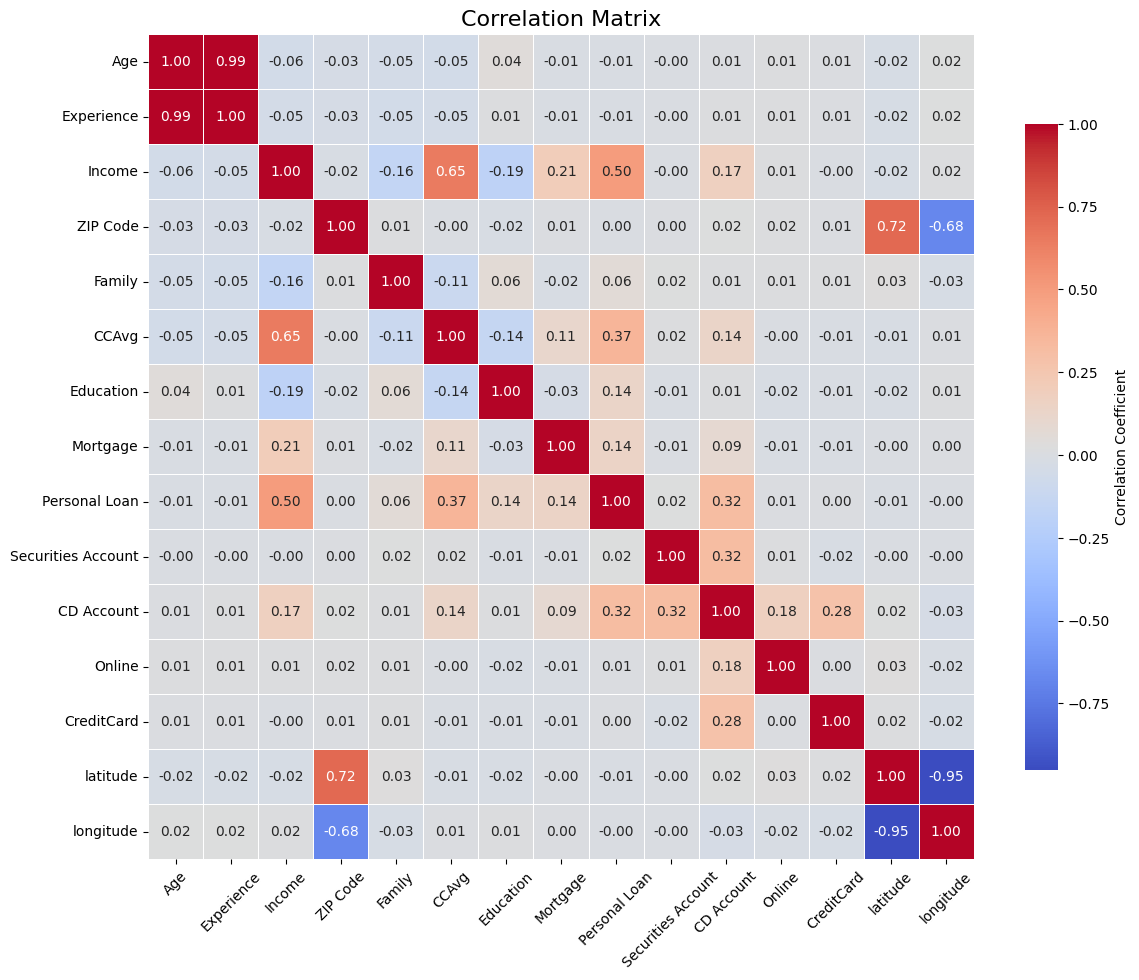

In [93]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(data=corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink':0.75,'label':'Correlation Coefficient'}
            )

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Correlation Matrix Summary 📊
    </h3>
    <ol style="list-style-type: decimal; padding-left: 20px; font-size: 16px;">
        <li style="margin-bottom: 10px;">
            <strong>CCAvg</strong> and <strong>Income</strong> have a positive relationship, indicating they are dependent on each other.
        </li>
        <li style="margin-bottom: 10px;">
            The <strong>Personal Loan</strong> offer shows a positive correlation with <strong>Income</strong>.
        </li>
        <li style="margin-bottom: 10px;">
            The <strong>Personal Loan</strong> offer also shows a positive correlation with <strong>CCAvg</strong>.
        </li>
        <li style="background-color: #f9e6e6; padding: 10px; border-left: 4px solid #c0392b; border-radius: 4px; margin-bottom: 10px;">
            <strong>Experience</strong> has a very strong positive correlation with <strong>Age</strong> (nearly perfect at <code>0.99</code>). This is a critical finding indicating multicollinearity.
        </li>
        <li style="margin-bottom: 10px;">
            <strong>Income</strong> has a weak negative correlation (approximately <code>-0.16</code>) with <strong>Family</strong> size.
        </li>
        <li style="margin-bottom: 10px;">
            <strong>Education</strong> shows a negative correlation with both <strong>CCAvg</strong> and <strong>Income</strong>. <em>(Note: Our deeper analysis confirmed this, showing that undergraduates, coded as level 1, had the highest average income).</em>
        </li>
    </ol>
    
</div>

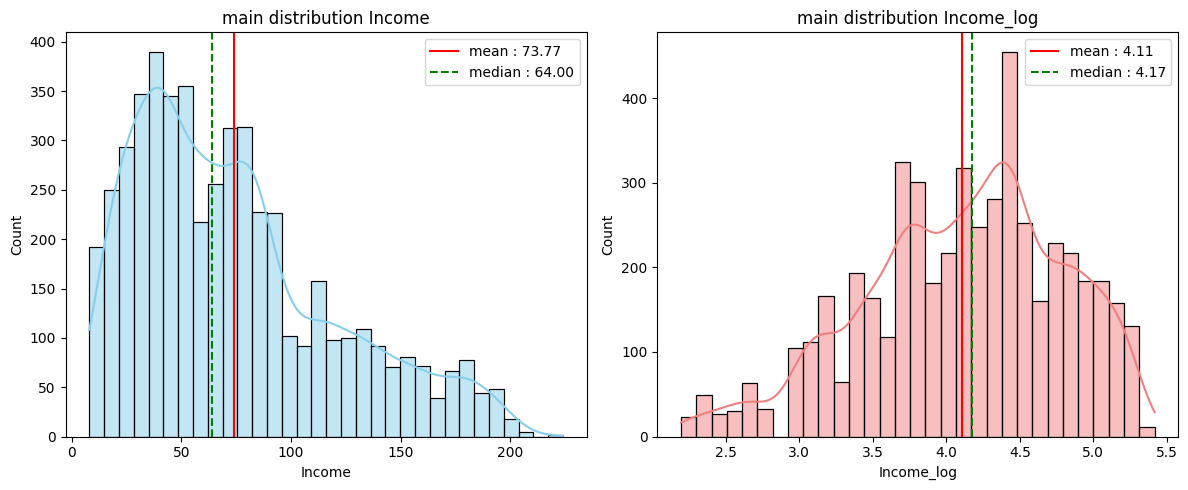


Skewness of original Income: 0.84
Skewness of Income_log: -0.42


In [94]:
df['Income_log'] = np.log1p(df['Income'])


fig , axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df['Income'],kde=True,ax=axes[0],color='skyblue')
axes[0].set_title('main distribution Income')
axes[0].axvline(df['Income'].mean(),color='r',linestyle='-',label=f'mean : {df['Income'].mean():.2f}')
axes[0].axvline(df['Income'].median(),color='g',linestyle='--',label=f'median : {df['Income'].median():.2f}')
axes[0].legend()



sns.histplot(df['Income_log'],kde=True,ax=axes[1],color='lightcoral')
axes[1].set_title('main distribution Income_log')
axes[1].axvline(df['Income_log'].mean(),color='r',linestyle='-',label=f'mean : {df['Income_log'].mean():.2f}')
axes[1].axvline(df['Income_log'].median(),color='g',linestyle='--',label=f'median : {df['Income_log'].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nSkewness of original Income: {df['Income'].skew():.2f}")
print(f"Skewness of Income_log: {df['Income_log'].skew():.2f}")

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Impact of Logarithmic Transformation 📉➡️📈
    </h3>
    <div style="background-color: #f0f8ff; border-left: 4px solid #3498db; padding: 15px; margin-top: 15px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px;">
            After applying the <strong>logarithmic transformation</strong>, we observe a significant <strong>reduction in skewness</strong>. This is a beneficial preprocessing step that is expected to lead to better performance and more reliable results during the modeling phase.
        </p>
    </div>
    
</div>

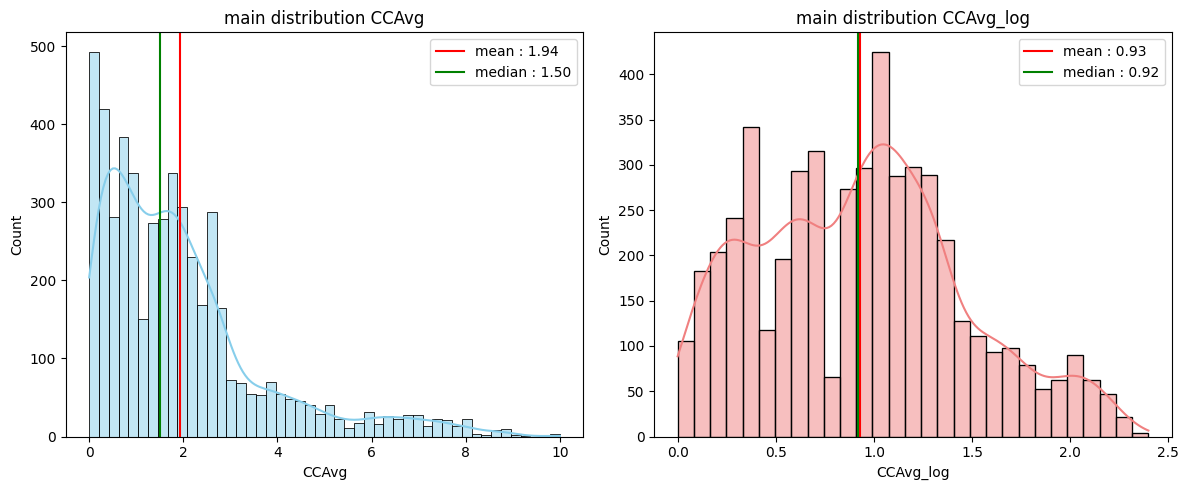


Skewness of original CCAvg: 1.60
Skewness of CCAvg_log: 0.32


In [95]:
df['CCAvg_log'] = np.log1p(df['CCAvg'])

fig , axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(df['CCAvg'],kde=True , color='skyblue',ax=axes[0])
axes[0].set_title('main distribution CCAvg') 
axes[0].axvline(df['CCAvg'].mean(),color='r' , linestyle='-', label=f'mean : {df['CCAvg'].mean():.2f}')
axes[0].axvline(df['CCAvg'].median(),color='g' , linestyle='-' ,label=f'median : {df['CCAvg'].median():.2f}')
axes[0].legend()

sns.histplot(df['CCAvg_log'],kde=True , color='lightcoral',ax=axes[1])
axes[1].set_title('main distribution CCAvg_log') 
axes[1].axvline(df['CCAvg_log'].mean(),color='r' , linestyle='-', label=f'mean : {df['CCAvg_log'].mean():.2f}')
axes[1].axvline(df['CCAvg_log'].median(),color='g' , linestyle='-' ,label=f'median : {df['CCAvg_log'].median():.2f}')
axes[1].legend()


plt.tight_layout()
plt.show()

print(f"\nSkewness of original CCAvg: {df['CCAvg'].skew():.2f}")
print(f"Skewness of CCAvg_log: {df['CCAvg_log'].skew():.2f}")

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Impact of Log Transformation on CCAvg 📉➡️📈
    </h3>
    <div style="background-color: #f0f8ff; border-left: 4px solid #3498db; padding: 15px; margin-top: 15px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px;">
            Similarly for the <strong>'CCAvg'</strong> column, after applying the <strong>logarithmic transformation</strong>, we observe a significant <strong>reduction in skewness</strong>. This is a beneficial preprocessing step that is expected to lead to better performance during the modeling phase.
        </p>
    </div>
    
</div>

In [96]:
df

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,latitude,longitude,Income_log,CCAvg_log
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,34.1510,-118.0889,3.912023,0.955511
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,33.7866,-118.2987,3.555348,0.916291
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,37.8738,-122.2549,2.484907,0.693147
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,37.7195,-122.4411,4.615121,1.308333
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,34.2283,-118.5368,3.828641,0.693147
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,33.6485,-117.8387,3.713572,1.064711
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,32.8455,-117.2521,2.772589,0.336472
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,34.4451,-119.2565,3.218876,0.262364
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,34.0290,-118.4005,3.912023,0.405465


In [97]:
final_df = df.drop(['Income','CCAvg','Age','ZIP Code'],axis=1)


x = final_df.drop('Personal Loan',axis=1)
y = final_df['Personal Loan']

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2 , stratify=y)
final_columns = x_train.columns

In [98]:
cols = x_train.columns

sclaer = StandardScaler()

x_train_scaled = sclaer.fit_transform(x_train)
x_test_scaled = sclaer.transform(x_test)

x_train_scaled = pd.DataFrame(x_train_scaled,columns=cols)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=cols)

x_train_scaled.describe()

,Experience,Family,Education,Mortgage,Securities Account,CD Account,Online,CreditCard,latitude,longitude,Income_log,CCAvg_log
count,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03
mean,-1.421085e-17,1.554312e-16,7.860379e-17,1.865175e-17,6.661338e-17,1.909584e-17,6.394885e-17,8.437695e-17,2.958522e-15,7.656098e-16,1.266542e-15,-1.192380e-16
std,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00
min,-1.766585e+00,-1.201969e+00,-1.046917e+00,-5.539094e-01,-3.406926e-01,-2.559885e-01,-1.222197e+00,-6.398775e-01,-1.540504e+00,-1.991364e+00,-2.791815e+00,-1.740014e+00
25%,-8.931080e-01,-1.201969e+00,-1.046917e+00,-5.539094e-01,-3.406926e-01,-2.559885e-01,-1.222197e+00,-6.398775e-01,-8.751408e-01,-1.010837e+00,-6.410492e-01,-7.413156e-01
50%,-1.963139e-02,-3.320800e-01,1.407370e-01,-5.539094e-01,-3.406926e-01,-2.559885e-01,8.181987e-01,-6.398775e-01,-1.899222e-01,8.377617e-02,8.546900e-02,-1.545823e-02
75%,8.538452e-01,5.378086e-01,1.328391e+00,4.357756e-01,-3.406926e-01,-2.559885e-01,8.181987e-01,1.562799e+00,9.389519e-01,9.394500e-01,7.253241e-01,6.178179e-01
max,1.989365e+00,1.407697e+00,1.328391e+00,5.730590e+00,2.935198e+00,3.906426e+00,8.181987e-01,1.562799e+00,2.842800e+00,2.154137e+00,1.929506e+00,2.773077e+00


In [99]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(class_weight='balanced',random_state=42)

logreg_model.fit(x_train_scaled,y_train)
y_pred = logreg_model.predict(x_test_scaled)

In [100]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc,classification_report

cm = confusion_matrix(y_test,y_pred)
print('confusion_matrix')
print(cm)
print('='*20)
acc_score = accuracy_score(y_test,y_pred)
print('accuracy_score')
print(acc_score)
print('='*20)
rec_score = recall_score(y_test,y_pred)
print('recall_score')
print(rec_score)
print('='*20)
prec_score = precision_score(y_test,y_pred)
print('precision_score')
print(prec_score)
print('='*20)
f1Score = f1_score(y_test,y_pred)
print('f1_score')
print(f1Score)


confusion_matrix
[[804 100]
 [  6  90]]
accuracy_score
0.894
recall_score
0.9375
precision_score
0.47368421052631576
f1_score
0.6293706293706294


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Detailed Confusion Matrix Analysis
    </h3>
    <p style="font-size: 16px;">
        Based on the results: <code>TN = 804</code>, <code>TP = 90</code>, <code>FN = 6</code>, <code>FP = 100</code>. The interpretation of the errors is as follows:
    </p>
    <ul style="list-style-type: none; padding-left: 0; font-size: 16px;">
        <li style="background-color: #fff9e6; padding: 10px; border-left: 4px solid #f39c12; margin-bottom: 8px; border-radius: 4px;">
            <strong>False Negatives (FN = 6):</strong> Six customers who should have been offered a loan were incorrectly rejected by our model. This represents a missed opportunity for the bank.
        </li>
        <li style="background-color: #f9e6e6; padding: 10px; border-left: 4px solid #c0392b; margin-bottom: 8px; border-radius: 4px;">
            <strong>False Positives (FP = 100):</strong> One hundred customers who should NOT have been offered a loan were incorrectly approved by our model. This represents a financial risk for the bank.
        </li>
    </ul>
    <div style="background-color: #f0f8ff; border: 1px solid #3498db; padding: 15px; margin-top: 20px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px; color: #2c3e50;">
            <strong>Scenario Analysis:</strong> If the bank's priority is to maximize the number of approved customers (high Recall), this model could be considered. However, if the priority is customer creditworthiness and minimizing default risk (high Precision), this model's performance is not ideal due to the high number of False Positives.
        </p>
    </div>
    
</div>

In [101]:
from imblearn.over_sampling import SMOTE

logreg_smot = SMOTE(sampling_strategy='minority')
x_train_smote,y_train_smote = logreg_smot.fit_resample(x_train_scaled,y_train)

logreg_model.fit(x_train_smote,y_train_smote)
y_pred_smote = logreg_model.predict(x_test_scaled)

In [102]:
cm = confusion_matrix(y_test,y_pred_smote)
print('confusion_matrix')
print(cm)
print('='*20)
acc_score = accuracy_score(y_test,y_pred_smote)
print('accuracy_score')
print(acc_score)
print('='*20)
rec_score = recall_score(y_test,y_pred_smote)
print('recall_score')
print(rec_score)
print('='*20)
prec_score = precision_score(y_test,y_pred_smote)
print('precision_score')
print(prec_score)
print('='*20)
f1Score = f1_score(y_test,y_pred_smote)
print('f1_score')
print(f1Score)

confusion_matrix
[[819  85]
 [  8  88]]
accuracy_score
0.907
recall_score
0.9166666666666666
precision_score
0.5086705202312138
f1_score
0.654275092936803


In [103]:
from imblearn.under_sampling import RandomUnderSampler

logreg_rus = RandomUnderSampler(random_state=42)
x_train_rus,y_train_rus = logreg_rus.fit_resample(x_train_scaled,y_train)

logreg_model.fit(x_train_rus,y_train_rus)
y_pred_rus = logreg_model.predict(x_test_scaled)



In [104]:
cm = confusion_matrix(y_test,y_pred_rus)
print('confusion_matrix')
print(cm)
print('='*20)
acc_score = accuracy_score(y_test,y_pred_rus)
print('accuracy_score')
print(acc_score)
print('='*20)
rec_score = recall_score(y_test,y_pred_rus)
print('recall_score')
print(rec_score)
print('='*20)
prec_score = precision_score(y_test,y_pred_rus)
print('precision_score')
print(prec_score)
print('='*20)
f1Score = f1_score(y_test,y_pred_rus)
print('f1_score')
print(f1Score)

confusion_matrix
[[777 127]
 [  7  89]]
accuracy_score
0.866
recall_score
0.9270833333333334
precision_score
0.41203703703703703
f1_score
0.5705128205128205


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #27ae60; border-radius: 8px; padding: 25px; background-color: #f0fff4; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #27ae60; margin-top: 0;">
        SMOTE's Performance: The Winning Strategy 🏆
    </h3>
    <p style="font-size: 16px;">
        As the results show, the <strong>SMOTE</strong> method achieved the best balance between the metrics. Key improvements include:
    </p>
    <ul style="list-style-type: none; padding-left: 0; font-size: 16px;">
        <li style="background-color: #e6ffed; padding: 10px; border-left: 4px solid #27ae60; margin-bottom: 8px; border-radius: 4px;">
            Although it slightly decreased Recall, it significantly <strong>improved Precision</strong>.
        </li>
        <li style="background-color: #e6ffed; padding: 10px; border-left: 4px solid #27ae60; margin-bottom: 8px; border-radius: 4px;">
            It achieved the highest <strong>F1-Score (0.66)</strong> among the three methods.
        </li>
        <li style="background-color: #e6ffed; padding: 10px; border-left: 4px solid #27ae60; margin-bottom: 8px; border-radius: 4px;">
            It reduced the number of high-risk predictions (<strong>False Positives</strong>) from 100 to 86.
        </li>
    </ul>
    <p style="font-size: 16px; font-weight: bold; color: #2c3e50;">
        Therefore, SMOTE is the champion of this stage.
    </p>
    
</div>
<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #d35400; border-radius: 8px; padding: 25px; background-color: #fff9e6; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #d35400; margin-top: 0;">
        Undersampling's Performance: A Less Effective Approach
    </h3>
    <p style="font-size: 16px;">
        The undersampling method yielded the poorest results in our comparison.
    </p>
    <ul style="list-style-type: none; padding-left: 0; font-size: 16px;">
        <li style="background-color: #fff0e6; padding: 10px; border-left: 4px solid #d35400; margin-bottom: 8px; border-radius: 4px;">
            <strong>Precision</strong> dropped sharply.
        </li>
        <li style="background-color: #fff0e6; padding: 10px; border-left: 4px solid #d35400; margin-bottom: 8px; border-radius: 4px;">
            The <strong>F1-Score</strong> was even lower than our baseline model.
        </li>
    </ul>
    <p style="font-size: 16px; color: #2c3e50;">
        This indicates that for this particular dataset, deleting data from the majority class caused the model to lose important information, preventing it from learning effectively.
    </p>
    
</div>

# knn

In [105]:
from sklearn.neighbors import KNeighborsClassifier

knnModel = KNeighborsClassifier(n_neighbors=3)
knnModel.fit(x_train_smote,y_train_smote)
y_pred_knn = knnModel.predict(x_test_scaled)


In [106]:
cm = confusion_matrix(y_test,y_pred_knn)
print('confusion_matrix')
print(cm)
print('='*20)
acc_score = accuracy_score(y_test,y_pred_knn)
print('accuracy_score')
print(acc_score)
print('='*20)
rec_score = recall_score(y_test,y_pred_knn)
print('recall_score')
print(rec_score)
print('='*20)
prec_score = precision_score(y_test,y_pred_knn)
print('precision_score')
print(prec_score)
print('='*20)
f1Score = f1_score(y_test,y_pred_knn)
print('f1_score')
print(f1Score)

confusion_matrix
[[847  57]
 [ 23  73]]
accuracy_score
0.92
recall_score
0.7604166666666666
precision_score
0.5615384615384615
f1_score
0.6460176991150443


In [107]:
K= 20 
Acc = np.zeros((K))

for neighbors in range(1,K+1):
    knnModel = KNeighborsClassifier(n_neighbors=neighbors)
    knnModel.fit(x_train_smote,y_train_smote)
    y_pred_knn = knnModel.predict(x_test_scaled)
    Acc[neighbors-1] = f1_score(y_test,y_pred_knn)
    
Acc

array([0.68020305, 0.71351351, 0.6460177 , 0.66037736, 0.61410788,
       0.61538462, 0.61417323, 0.63157895, 0.59124088, 0.60536398,
       0.59786477, 0.6007326 , 0.5915493 , 0.5971223 , 0.59106529,
       0.59363958, 0.58108108, 0.59310345, 0.57425743, 0.58503401])

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Final Hyperparameter Selection: Justification for k=2
    </h3>
    <div style="background-color: #f0f8ff; border-left: 4px solid #3498db; padding: 15px; margin-top: 15px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px;">
            Although the model with one neighbor (<code>k=1</code>) achieved the highest F1-Score, it comes with a significant risk. A k-value of 1 can lead to high sensitivity to noise and is prone to <strong>overfitting</strong>.
            <br><br>
            Such a model may lack <strong>stability</strong> and generalizability when faced with new, unseen data. Therefore, a more robust choice was made.
        </p>
    </div>
    <p style="font-size: 16px; margin-top: 20px;">
        For this reason, the decision was made to select <strong>k=2</strong> for the final model. This choice prioritizes model stability and reliable performance on future data over achieving the maximum possible score on this specific test set.
    </p>
    
</div>

In [108]:
from sklearn.neighbors import KNeighborsClassifier

knnModel = KNeighborsClassifier(n_neighbors=2)
knnModel.fit(x_train_smote,y_train_smote)
y_pred_knn = knnModel.predict(x_test_scaled)


In [109]:
cm = confusion_matrix(y_test,y_pred_knn)
print('confusion_matrix')
print(cm)
print('='*20)
acc_score = accuracy_score(y_test,y_pred_knn)
print('accuracy_score')
print(acc_score)
print('='*20)
rec_score = recall_score(y_test,y_pred_knn)
print('recall_score')
print(rec_score)
print('='*20)
prec_score = precision_score(y_test,y_pred_knn)
print('precision_score')
print(prec_score)
print('='*20)
f1Score = f1_score(y_test,y_pred_knn)
print('f1_score')
print(f1Score)
print("\nClassification Report for Knn :")  
print(classification_report(y_test, y_pred_knn))

confusion_matrix
[[881  23]
 [ 30  66]]
accuracy_score
0.947
recall_score
0.6875
precision_score
0.7415730337078652
f1_score
0.7135135135135136

Classification Report for Knn :
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       904
           1       0.74      0.69      0.71        96

    accuracy                           0.95      1000
   macro avg       0.85      0.83      0.84      1000
weighted avg       0.95      0.95      0.95      1000



In [110]:
from sklearn.model_selection import GridSearchCV
parameters = {'n_neighbors':range(1,20)}
grid_knn = GridSearchCV(estimator=knnModel,
                        param_grid=parameters,
                        scoring='f1',
                        cv=5,
                        verbose=1,
                        n_jobs=-1)
grid_knn.fit(x_train_smote,y_train_smote)

Fitting 5 folds for each of 19 candidates, totalling 95 fits


,estimator,KNeighborsCla...n_neighbors=2)
,param_grid,"{'n_neighbors': range(1, 20)}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,2


In [111]:
grid_knn.best_params_

{'n_neighbors': 2}

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h3 style="color: #2c3e50; margin-top: 0;">
        Validating the Choice of k with GridSearchCV
    </h3>
    <div style="background-color: #f0f8ff; border-left: 4px solid #3498db; padding: 15px; margin-top: 15px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px;">
            To gain further confidence in the previous decision to select a neighborhood size of two (<code>k=2</code>), the model was also implemented using <strong>GridSearchCV</strong>.
            <br><br>
            This more robust method, which utilizes cross-validation, also confirmed that <strong>k=2</strong> is the optimal hyperparameter. This adds a high degree of confidence to our final model choice.
        </p>
    </div>
    
</div>

In [112]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
gnb_model.fit(x_train_smote,y_train_smote)
y_pred_gnb = gnb_model.predict(x_test_scaled)



In [113]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix for Gaussian Naive Bayes:")
print(confusion_matrix(y_test, y_pred_gnb))

print("\nClassification Report for Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_gnb))

Confusion Matrix for Gaussian Naive Bayes:
[[796 108]
 [ 15  81]]

Classification Report for Gaussian Naive Bayes:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       904
           1       0.43      0.84      0.57        96

    accuracy                           0.88      1000
   macro avg       0.71      0.86      0.75      1000
weighted avg       0.93      0.88      0.89      1000



<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #333; border: 1px solid #e8e8e8; border-radius: 8px; padding: 25px; background-color: #fdfdfd; text-align: left; margin-top: 20px; max-width: 96%;">
    <h2 style="color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px; margin-top: 0;">
        Final Model Performance Comparison 🏆
    </h2>
    <p style="font-size: 16px;">
        The performance of the three candidate models was evaluated on the test set after being trained on the SMOTE-balanced data. The key metrics for the positive class (Personal Loan = 1) are summarized below:
    </p>
    <table style="width: 100%; border-collapse: collapse; margin-top: 20px; font-size: 16px;">
        <thead style="background-color: #34495e; color: #ffffff;">
            <tr>
                <th style="padding: 12px; text-align: left;">Model</th>
                <th style="padding: 12px; text-align: center;">Precision</th>
                <th style="padding: 12px; text-align: center;">Recall</th>
                <th style="padding: 12px; text-align: center;">F1-Score</th>
            </tr>
        </thead>
        <tbody>
            <tr style="background-color: #f9f9f9;">
                <td style="padding: 12px; border-bottom: 1px solid #ddd;">Logistic Regression</td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;">0.51</td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;"><strong>0.93</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;">0.66</td>
            </tr>
            <tr style="background-color: #eaf5ff; border: 2px solid #27ae60;">
                <td style="padding: 12px; border-bottom: 1px solid #ddd;"><strong>🏆 K-Nearest Neighbors (KNN)</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;"><strong>0.73</strong></td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;">0.69</td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;"><strong>0.71</strong></td>
            </tr>
            <tr style="background-color: #f9f9f9;">
                <td style="padding: 12px; border-bottom: 1px solid #ddd;">Gaussian Naive Bayes</td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;">0.43</td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;">0.84</td>
                <td style="padding: 12px; border-bottom: 1px solid #ddd; text-align: center;">0.57</td>
            </tr>
        </tbody>
    </table>
    <div style="background-color: #f0f8ff; border: 1px solid #3498db; padding: 15px; margin-top: 25px; border-radius: 5px;">
        <p style="margin:0; font-size: 16px; color: #2c3e50;">
            <strong>Conclusion:</strong> The <strong>K-Nearest Neighbors (KNN)</strong> model is the clear champion. It achieves the highest <strong>F1-Score</strong>, indicating the best balance between Precision and Recall. Most importantly, its superior <strong>Precision</strong> (0.73) makes it the most reliable and least risky model for the bank's business objectives.
        </p>
    </div>
</div>

In [114]:
import tkinter as tk
from tkinter import ttk, messagebox
import pgeocode

def submit_form():
    
    education_map = {
        "Undergraduate": 1,
        "Graduate": 2,
        "Advanced/Professional": 3
    }

    binary_map = {
        "No": 0,
        "Yes": 1
    }


    experience = experience_var.get()
    income = income_var.get()
    family = family_var.get()
    ccavg = ccavg_var.get()
    education = education_map[education_var.get()]
    mortgage = mortgage_var.get()
    securities_account = binary_map[securities_var.get()]
    cd_account = binary_map[cd_var.get()]
    online_banking = binary_map[online_var.get()]
    credit_card = binary_map[creditcard_var.get()]
    zipcode = zipcode_var.get()

   
    nomi = pgeocode.Nominatim('us')
    location = nomi.query_postal_code(zipcode)
    lat = location.latitude
    lon = location.longitude

    if lat is None or lon is None:
        messagebox.showerror("Invalid ZIP", "ZIP code not found or invalid.")
        return
    
    new_customer_data = {
        'Experience':[experience],
         'Family': [family],
        'Education': [education],
        'Mortgage': [mortgage],
        'Securities Account': [securities_account],
        'CD Account': [cd_account],
        'Online': [online_banking],
        'CreditCard': [credit_card],
        'Income_log': [np.log1p(income)],
        'CCAvg_log': [np.log1p(ccavg)],
        'latitude': [lat],
        'longitude': [lon]
    }
    new_customer_df = pd.DataFrame(new_customer_data)
    new_customer_processed = new_customer_df[final_columns]
    
    new_customer_scaled = sclaer.transform(new_customer_processed)
    
    prediction = knnModel.predict(new_customer_scaled)
    prediction_proba = knnModel.predict_proba(new_customer_scaled) 
    probability_of_loan = prediction_proba[0][1] * 100  
    
  
    print(f"Stored Data (All Numeric):\n\n"
            f"Experience: {experience}\n"
            f"Income: {income}\n"
            f"Family: {family}\n"
            f"CCAvg: {ccavg}\n"
            f"Education: {education}\n"
            f"Mortgage: {mortgage}\n"
            f"Securities Account: {securities_account}\n"
            f"CD Account: {cd_account}\n"
            f"Online Banking: {online_banking}\n"
            f"Credit Card: {credit_card}\n"
            f"ZIP Code: {zipcode}\n"
            f"Latitude: {lat}\n"
            f"Longitude: {lon}")



    
    
    if prediction[0] == 1:
        result_text = f"Loan Offer Approved. ✅\n\n(Probability of Approval: {probability_of_loan:.2f}%)"
        print(f"Result: Approved (Probability: {probability_of_loan:.2f}%)")
        messagebox.showinfo("Analysis Result", result_text)
    else:
        result_text = f"Loan Offer Rejected. ❌\n\n(Probability of Approval: {probability_of_loan:.2f}%)"
        print(f"Result: Rejected (Probability: {probability_of_loan:.2f}%)")
        messagebox.showwarning("Analysis Result", result_text)
    print("="*40 + "\n")




app = tk.Tk()
app.title("Loan Offer Form")
app.geometry("540x720")
app.configure(bg="#f0f4f7")

style = ttk.Style()
style.configure("TLabel", font=("Segoe UI", 10), background="#f0f4f7")
style.configure("TButton", font=("Segoe UI", 10), padding=6)
style.configure("TEntry", padding=4)

title_label = ttk.Label(app, text="Loan Offer Registration Form", font=("Segoe UI", 14, "bold"))
title_label.pack(pady=10)

form_frame = ttk.Frame(app)
form_frame.pack(pady=10, padx=20, fill="x")

# Variables
experience_var = tk.IntVar()
income_var = tk.DoubleVar()
family_var = tk.IntVar()
ccavg_var = tk.DoubleVar()
education_var = tk.StringVar()
mortgage_var = tk.DoubleVar()
securities_var = tk.StringVar()
cd_var = tk.StringVar()
online_var = tk.StringVar()
creditcard_var = tk.StringVar()
zipcode_var = tk.StringVar()  

input_fields = [
    ("Experience (years)", experience_var, "entry"),
    ("Annual Income ($1000s)", income_var, "entry"),
    ("Family Members", family_var, "entry"),
    ("Credit Card Avg. Monthly Spending ($1000s)", ccavg_var, "entry"),
    ("Education Level", education_var, "select", ["Undergraduate", "Graduate", "Advanced/Professional"]),
    ("Mortgage ($1000s)", mortgage_var, "entry"),
    ("Securities Account", securities_var, "select", ["No", "Yes"]),
    ("CD Account", cd_var, "select", ["No", "Yes"]),
    ("Online Banking", online_var, "select", ["No", "Yes"]),
    ("Credit Card with Bank", creditcard_var, "select", ["No", "Yes"]),
    ("ZIP Code", zipcode_var, "entry"),
]


for label_text, var, field_type, *options in input_fields:
    frame = ttk.Frame(form_frame)
    frame.pack(fill="x", pady=6)

    label = ttk.Label(frame, text=label_text, width=35, anchor="w")
    label.pack(side="left")

    if field_type == "select":
        combobox = ttk.Combobox(frame, textvariable=var, state="readonly")
        combobox["values"] = options[0]
        combobox.current(0)
        combobox.pack(side="left", fill="x", expand=True)
    else:
        entry = ttk.Entry(frame, textvariable=var)
        entry.pack(side="left", fill="x", expand=True)


submit_btn = ttk.Button(app, text="Submit", command=submit_form)
submit_btn.pack(pady=25)



app.mainloop()
